<a href="https://colab.research.google.com/github/javmencia/RelativeBelief/blob/Round2/LinReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

## Bias Against

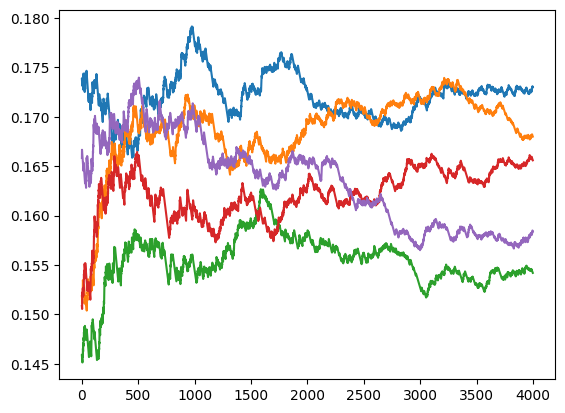

In [21]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,

    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]

import matplotlib.pyplot as plt
# Parameters
# Define prior parameters

sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,

        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

[5, 15, 25, 35, 45]


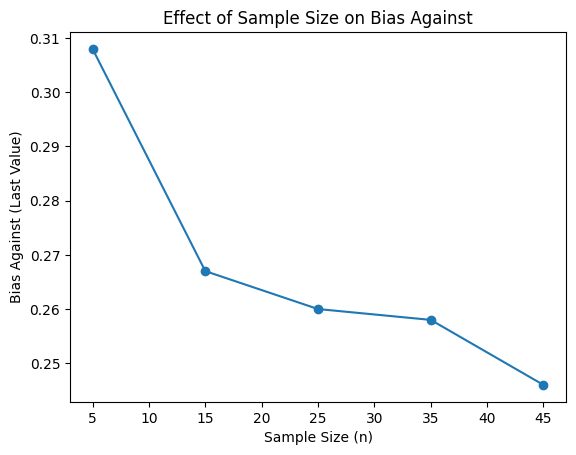

In [16]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


0
1
2
3
4
5


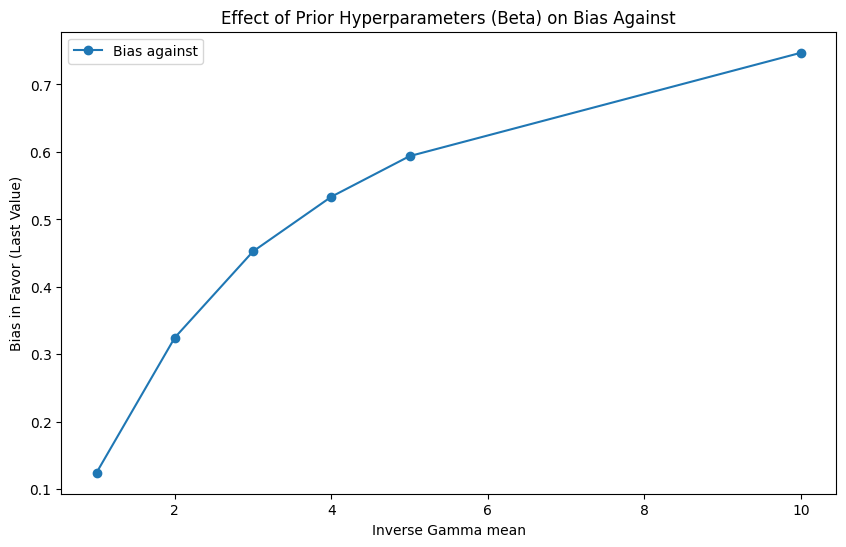

In [32]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]


# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)
        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot(beta_values, biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias Against')
plt.show()


0
1
2
3
4
5


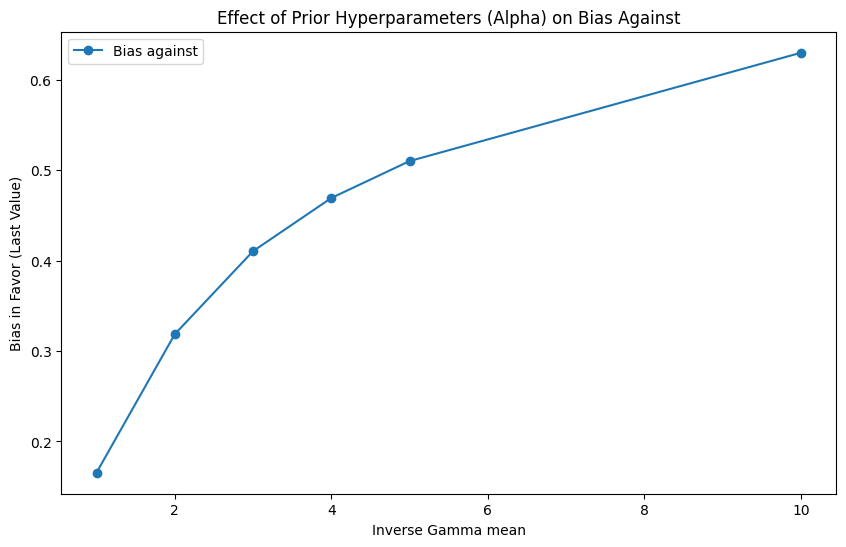

In [34]:

# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2, 2]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)

        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot([1,2,3,4,5,10], biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Alpha) on Bias Against')
plt.show()


# Bias in favor

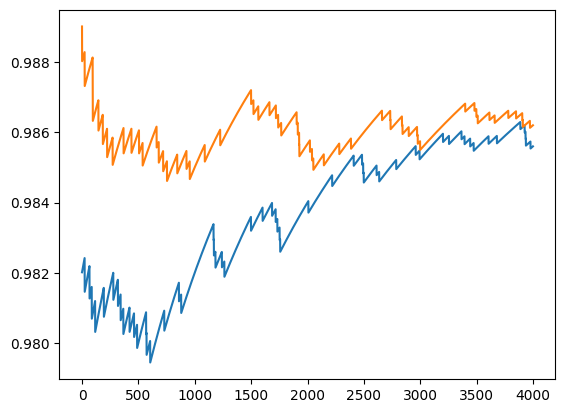

In [4]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]

# Parameters
# Define prior parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor)
plt.show()


In [24]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]


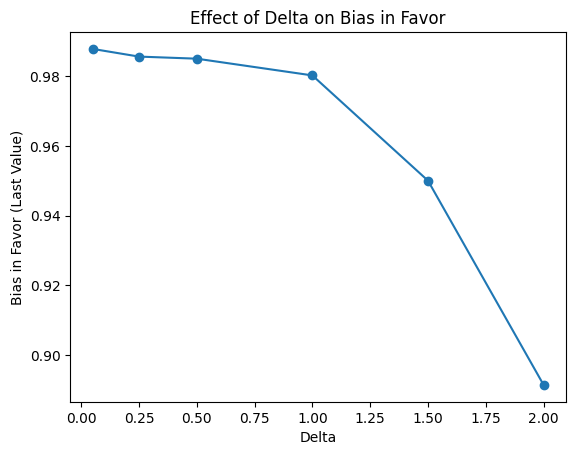

In [26]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.05, 0.25, 0.50, 1, 1.5, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(delta_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor")
plt.show()


[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
10
20
30
40
50
60
70
80
90
100


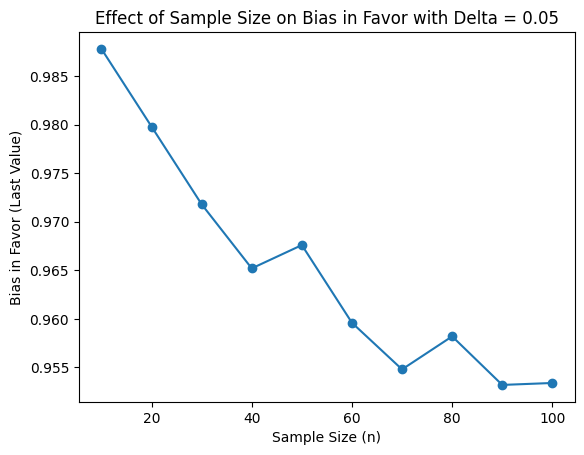

In [9]:

# Parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
for n in n_values:
    print(n)
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(n_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()


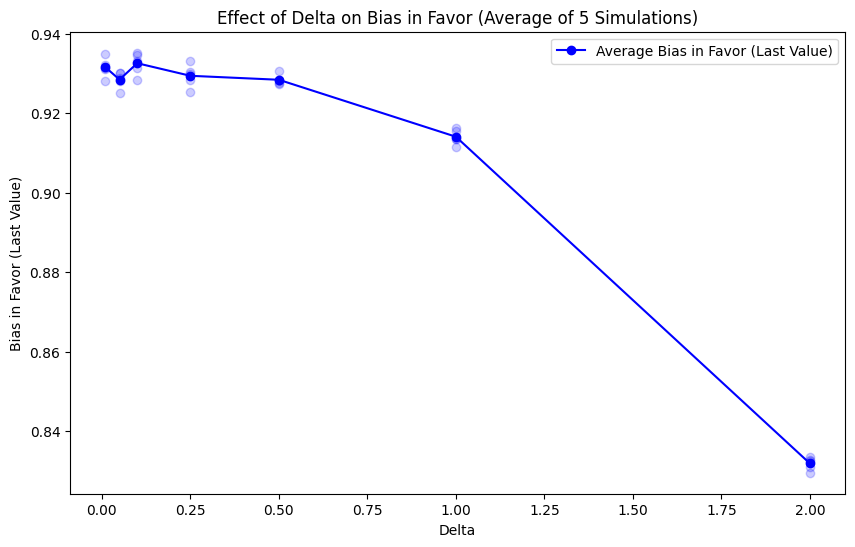

In [ ]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.01, 0.05, 0.10, 0.25, 0.50, 1, 2]
bias_in_favor_last_avg_values = []
all_bias_in_favor_last_values = []  # To store individual simulations for transparency

for delta in delta_values:
    # Run 5 simulations and collect results
    simulations = []
    for _ in range(5):
        bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
            n_sample=n,
            beta0=beta0,
            X=X,
            sigma0=sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=sigma_prior_alpha,
            sigma_prior_beta=sigma_prior_beta,
            delta=delta,
            cumulative=False,
            n_datasets=1000
        )
        simulations.append(bias_in_favor_last)

    # Average of the 5 simulations for current delta
    avg_bias_in_favor_last = np.mean(simulations)
    bias_in_favor_last_avg_values.append(avg_bias_in_favor_last)
    all_bias_in_favor_last_values.append(simulations)  # Store for plotting transparency

# Plotting
plt.figure(figsize=(10, 6))

# Plot individual simulations with transparency
for i, delta in enumerate(delta_values):
    plt.scatter([delta] * 5, all_bias_in_favor_last_values[i], color='blue', alpha=0.2)

# Plot the average of the 5 simulations for each delta
plt.plot(delta_values, bias_in_favor_last_avg_values, marker='o', color='blue', label='Average Bias in Favor (Last Value)')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor (Average of 5 Simulations)")
plt.legend()
plt.show()


### Changing the alpha hyperparameter

0
1


<ipython-input-28-e6fd1405c605>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


2
3
4
5


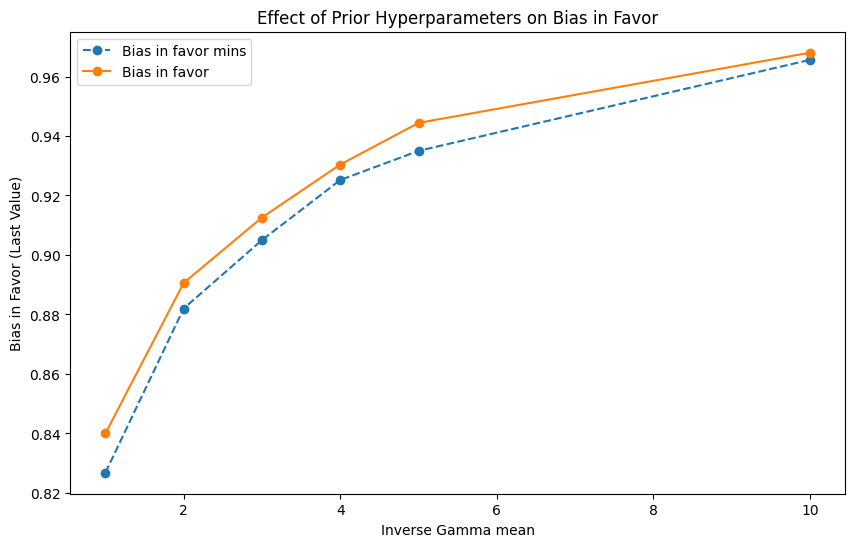

In [28]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot([1, 2, 3, 4, 5, 10] , mins, linestyle = "--", label = "Bias in favor mins", marker='o')
plt.plot([1, 2, 3, 4, 5, 10] , maxs, label = "Bias in favor", marker='o')
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


### Changing the beta hyperparameter

0


<ipython-input-30-8de1be8376f0>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


1
2
3
4
5


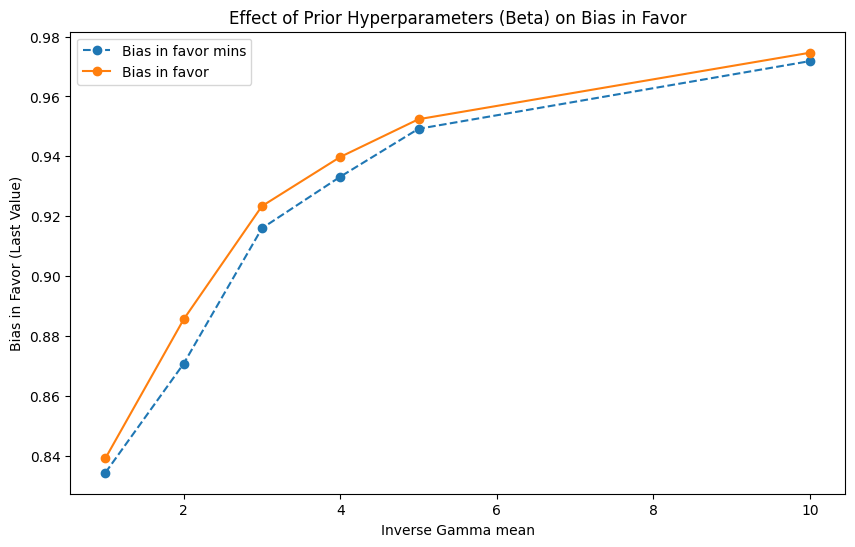

In [30]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot(beta_values, mins, linestyle = "--", label = "Bias in favor mins", marker = "o")
plt.plot(beta_values, maxs, label = "Bias in favor", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias in Favor')
plt.show()
